In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = AerSimulator()
# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


nb_qubits = 4

N = 2**nb_qubits
m = np.zeros((N,N))
for j in range(N):
    if j == N-1:
        break
    else:
       m[j,j+1] = -1 

for j in range(N):
    if j == N-1:
        break
    else:
       m[j+1,j] = -1 
for j in range(N):
   m[j,j] = 2 
m[0] = np.array([1]+ [0]*(N-1))
m[1,0] = 0

b = 0.25*np.array([0,1,1,1,1,1,1,1,1,1,1,1,1,2,0,0])
nb_qubits = 4

In [3]:
np.linalg.det(m)



15.999999999999984

In [4]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([1.52655666e-16+1.80411242e-16j, 2.50000000e-01+2.11636264e-15j,
       2.50000000e-01+1.85962357e-15j, 2.50000000e-01+1.74860126e-15j,
       2.50000000e-01-1.05471187e-15j, 2.50000000e-01-1.30451205e-15j,
       2.50000000e-01-1.49880108e-15j, 2.50000000e-01-1.74860126e-15j,
       2.50000000e-01-2.19269047e-15j, 2.50000000e-01-1.87350135e-15j,
       2.50000000e-01-1.66533454e-15j, 2.50000000e-01-1.41553436e-15j,
       2.50000000e-01+1.41553436e-15j, 5.00000000e-01+2.92821323e-15j,
       0.00000000e+00+8.32667268e-17j, 0.00000000e+00+1.84889275e-32j])

In [5]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(i,j,k,l):
        return np.kron(i,np.kron(j,np.kron(k,l)))
    M1 = (np.dot(np.dot(Ub,tensor(z,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,z,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,z,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I,I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [6]:
d,u = np.linalg.eig(A)
d

array([ 1.05409197e+01-9.76789505e-30j,  8.43423780e+00-4.80217939e-30j,
        7.03186296e+00+1.39251751e-29j,  6.13672278e+00-3.58158225e-29j,
        4.82453150e+00+1.81470163e-29j,  4.28987417e+00+2.92451276e-29j,
        2.63515514e+00+1.80148141e-31j,  1.78741871e+00-8.99093850e-30j,
        1.34598333e+00-4.40491932e-30j,  8.02047496e-01+3.30873270e-29j,
        5.85228713e-01+7.08078820e-30j,  3.49301362e-01+3.06709348e-29j,
        1.74677943e-01+3.95042419e-30j,  2.91479977e-02+1.23059217e-29j,
        6.39497219e-03+6.75197540e-30j, -4.68988464e-16-2.52434029e-31j])

In [7]:

U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
U5=scl.expm(2**4*2*np.pi*1j*A) 
U6=scl.expm(2**5*2*np.pi*1j*A) 
U7=scl.expm(2**6*2*np.pi*1j*A) 
U8=scl.expm(2**7*2*np.pi*1j*A)
 
u1gate = UnitaryGate(U1)
u2gate = UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)
u5gate=UnitaryGate(U5)
u6gate=UnitaryGate(U6)
u7gate=UnitaryGate(U7)
u8gate=UnitaryGate(U8)


C_u1gate=u1gate.control()
C_u2gate=u2gate.control()
C_u3gate=u3gate.control()
C_u4gate=u4gate.control()
C_u5gate=u5gate.control()
C_u6gate=u6gate.control()
C_u7gate=u7gate.control()
C_u8gate=u8gate.control()
    

[0.98600511 0.39693224 0.72089462 0.36135681 0.39371065 0.64181
 0.54087274 0.15596923 0.42179262 0.51678456 0.22916061 0.66736852
 0.06578829 0.18780831 0.90302615 0.61387919 0.07571959 0.78783502
 0.80335611 0.8656569  0.36694413 0.56447486 0.49885888 0.85887889
 0.21442787 0.8140991  0.17225246 0.09192131 0.48053858 0.1978216
 0.83790844 0.34412944 0.3005543  0.33562501 0.44945517 0.06735328]


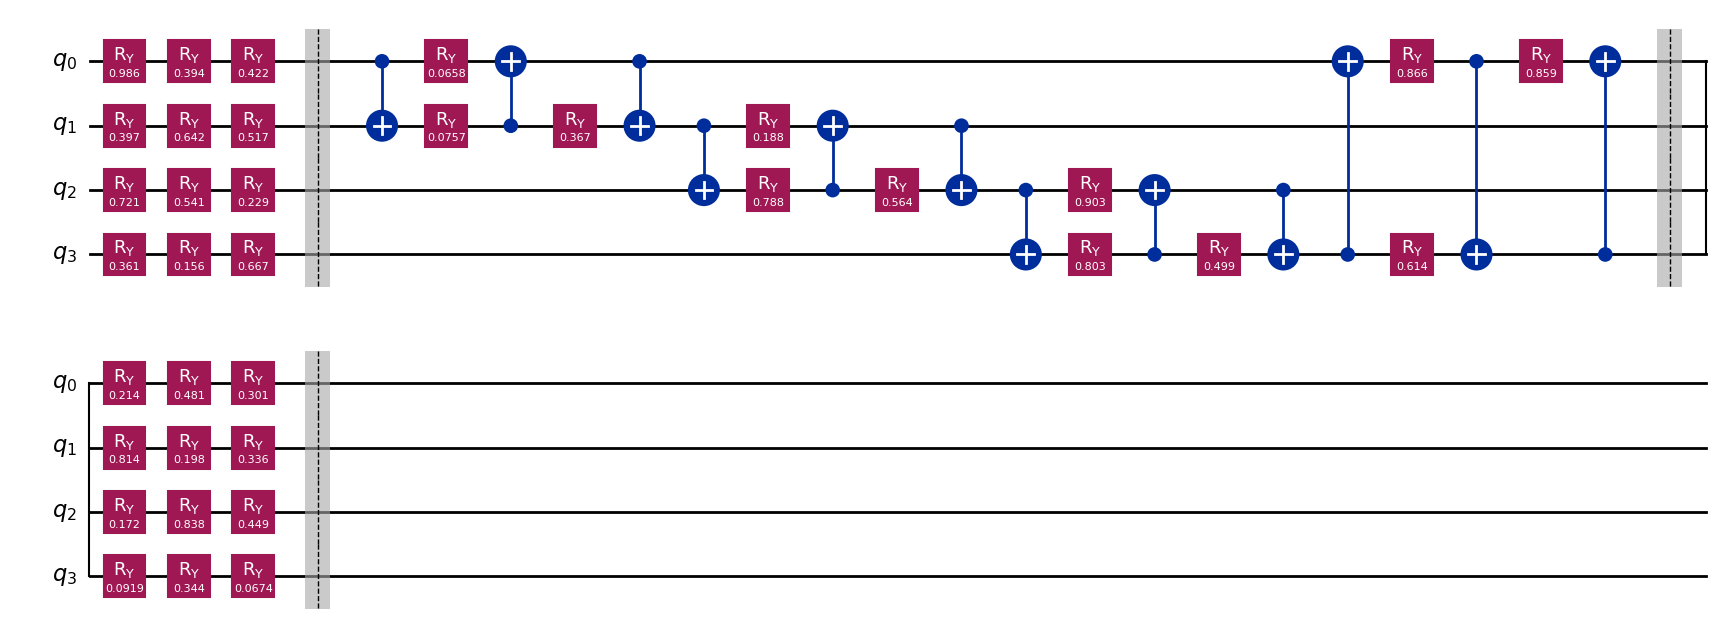

In [8]:
def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc

nb_qubits=4
depth=1
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)
# Parameters = np.array([random.random() for _ in range(0, nb_params)])

Parameters = np.array([0.98600511, 0.39693224, 0.72089462, 0.36135681, 0.39371065, 0.64181,
 0.54087274, 0.15596923, 0.42179262, 0.51678456, 0.22916061, 0.66736852,
 0.06578829, 0.18780831, 0.90302615, 0.61387919, 0.07571959, 0.78783502,
 0.80335611, 0.8656569,  0.36694413, 0.56447486, 0.49885888, 0.85887889,
 0.21442787, 0.8140991,  0.17225246, 0.09192131, 0.48053858, 0.1978216,
 0.83790844, 0.34412944, 0.3005543,  0.33562501, 0.44945517, 0.06735328])
print(Parameters)
ansatz(Parameters).draw("mpl")

In [10]:

def circ(parameters):
    x=QuantumRegister(12)
    c=ClassicalRegister(8)
    circuit = QuantumCircuit(x,c)

    circuit=circuit.compose(ansatz(parameters),x[8:12])
    circuit.h(x[0:8]) 
    circuit.append(C_u1gate, [x[0],x[8],x[9],x[10],x[11]])    
    circuit.append(C_u2gate, [x[1],x[8],x[9],x[10],x[11]])    
    circuit.append(C_u3gate, [x[2],x[8],x[9],x[10],x[11]])    
    circuit.append(C_u4gate, [x[3],x[8],x[9],x[10],x[11]]) 
    circuit.append(C_u5gate, [x[4],x[8],x[9],x[10],x[11]]) 
    circuit.append(C_u6gate, [x[5],x[8],x[9],x[10],x[11]]) 
    circuit.append(C_u7gate, [x[6],x[8],x[9],x[10],x[11]]) 
    circuit.append(C_u8gate, [x[7],x[8],x[9],x[10],x[11]]) 
    circuit &= QFT(num_qubits=8, approximation_degree=0, do_swaps=True, 
                   inverse=True, insert_barriers=False, name='qft')
    circuit.measure(x[0:8],c)       
    return circuit

/tmp/ipykernel_1773316/3672667775.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits=8, approximation_degree=0, do_swaps=True,


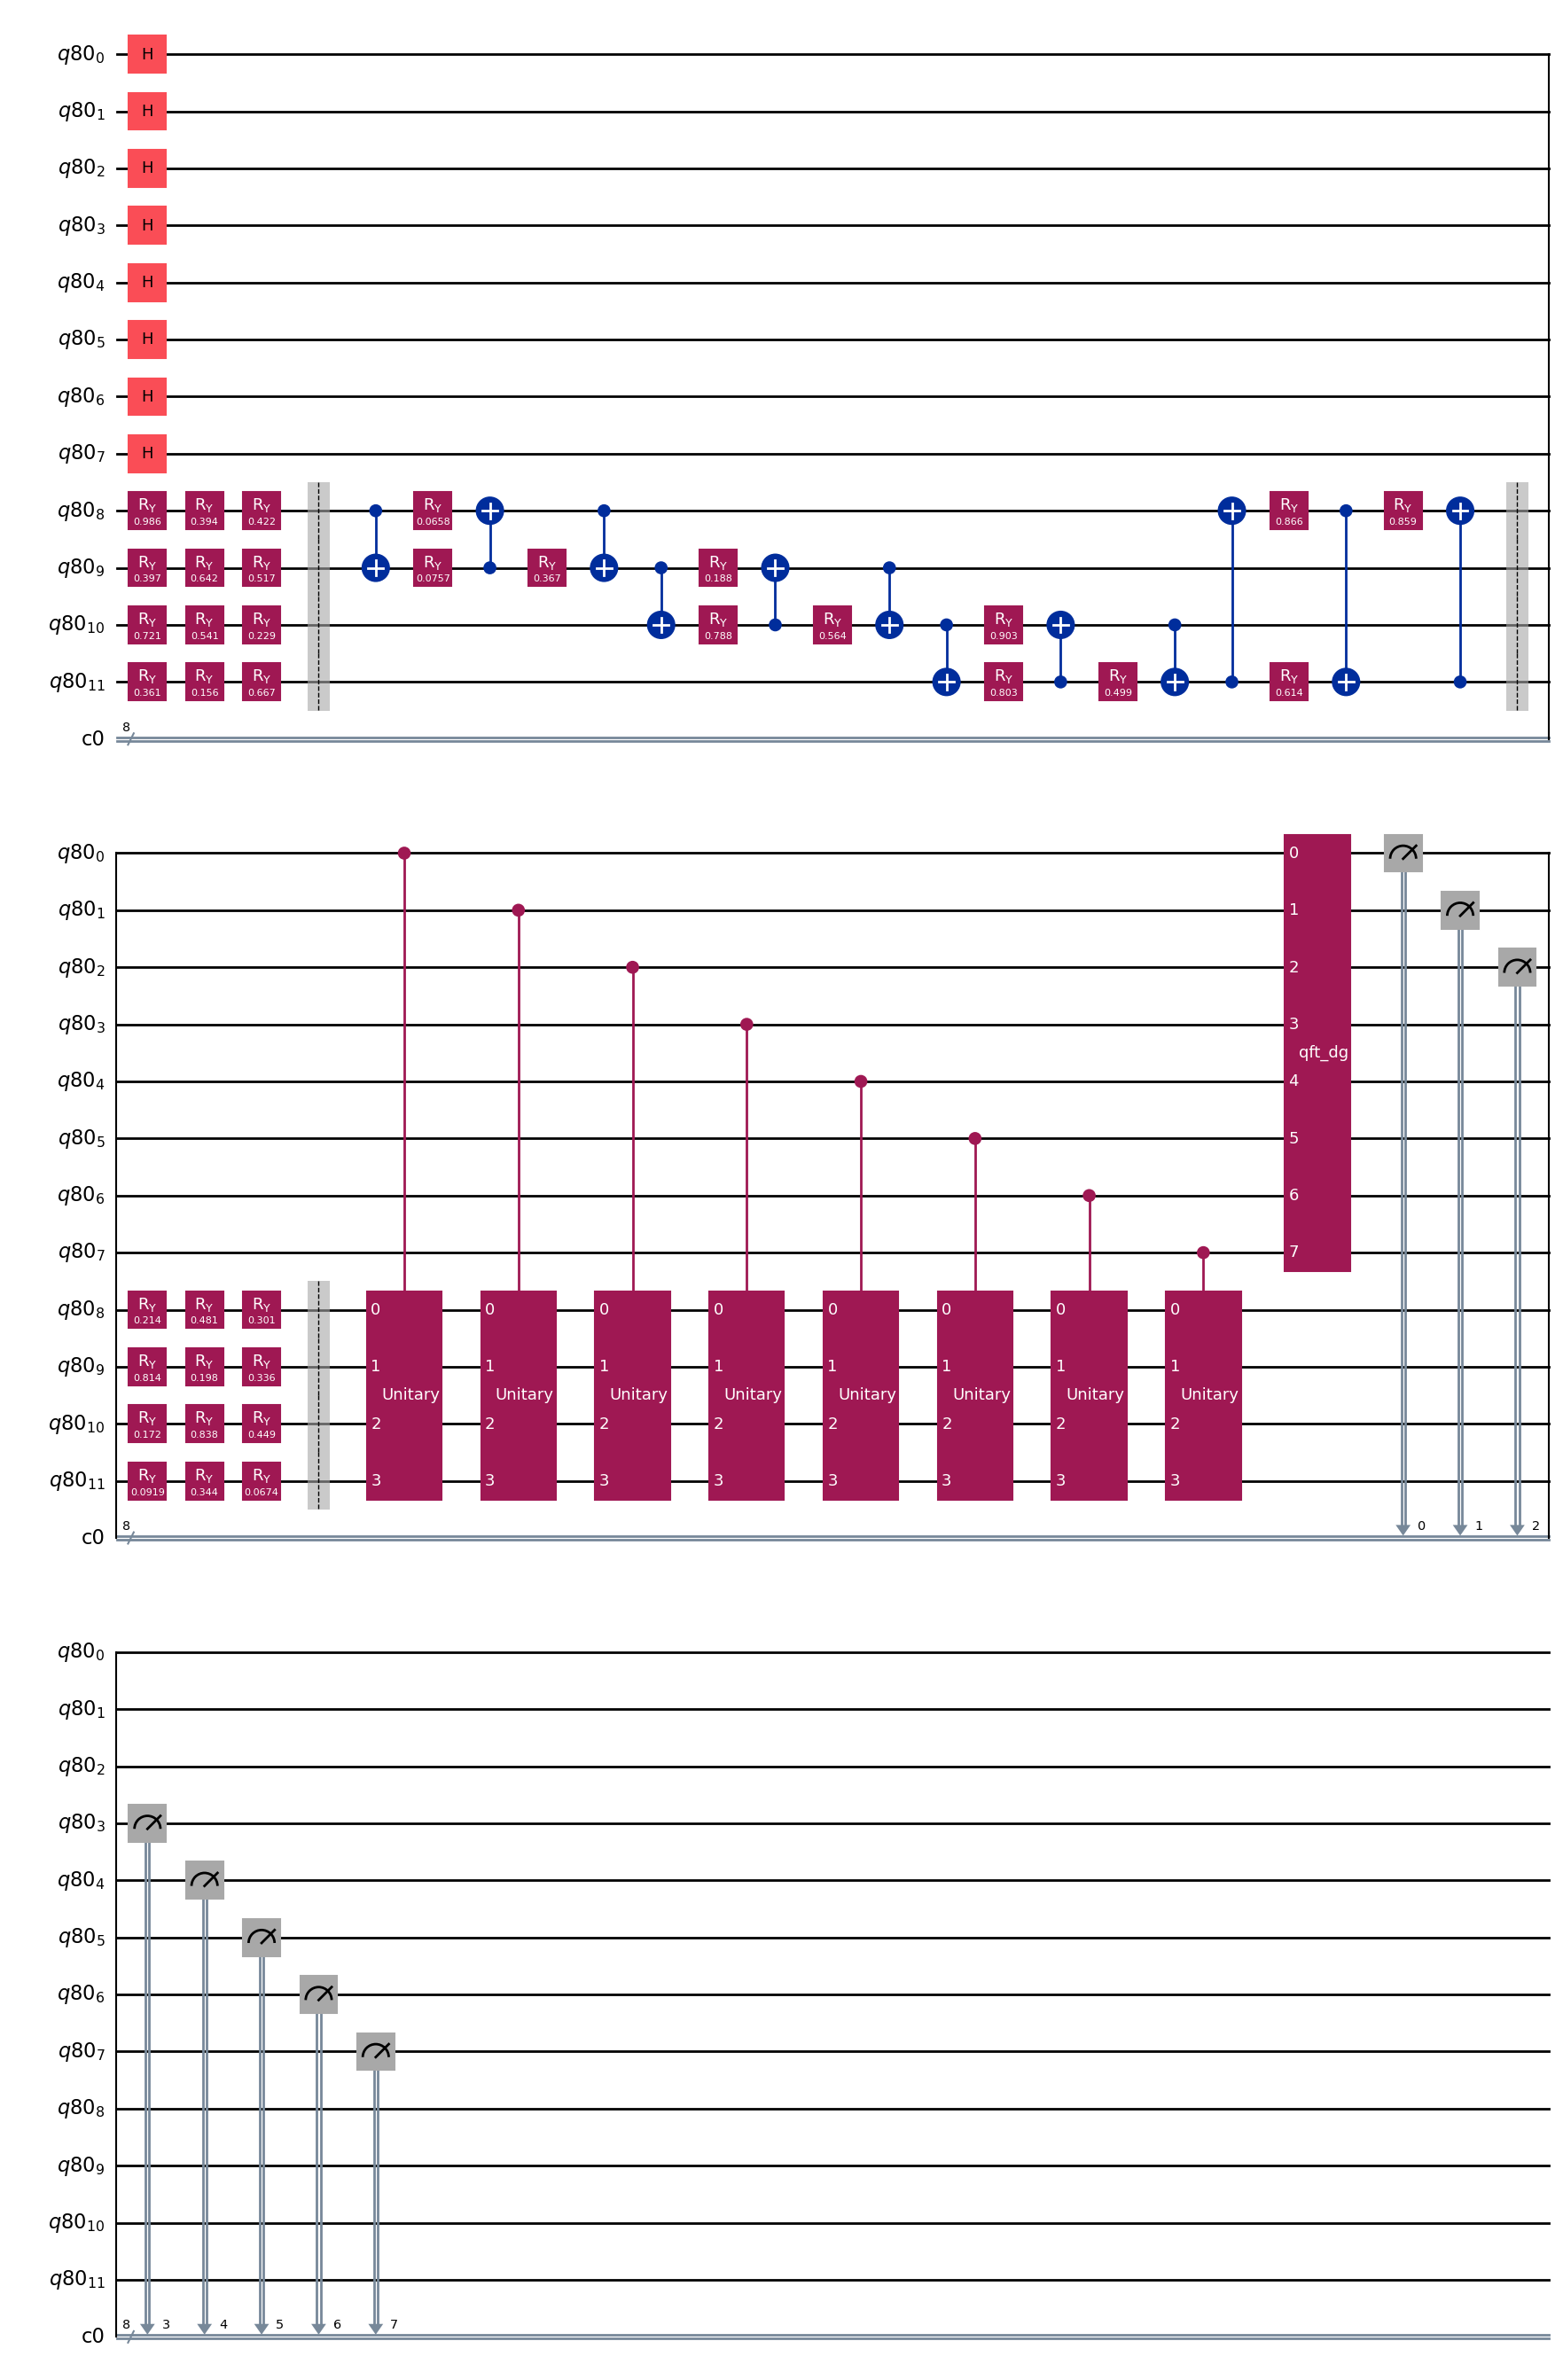

In [11]:
circ(Parameters).draw("mpl") 

In [12]:
shots = 100000
def cost(Parameters):
    # qct = transpile(qc,basis_gates = ['cx','id', 'x', 'rx', 'rz'])
    # Noise_sim = AerSimulator.from_backend(backend)
    job = backend.run(pm.run(circ(Parameters)),shots = shots).result()
    result = job.get_counts(0)
    if '00000000'not in result: 
        res = 1
    else:
        res = 1 - result['00000000']/shots
    return res
# cost(parameters)


In [13]:
import warnings
warnings.filterwarnings("ignore")
from qiskit_algorithms.optimizers import SPSA
def save(nfev, Parameters, cost, learning_rate, trust_region):
    
    global Cost,Params
    Cost.append(cost)
    Params.append(Parameters)
    print(nfev, cost)
Cost = []
Params = []
spsa = SPSA(maxiter=3000, callback =save)
spsa.minimize(cost, Parameters)
# print(Cost)
    

3 0.90662
6 0.8986
9 0.8904799999999999
12 0.8877
15 0.88084
18 0.94516
21 0.92305
24 0.89915
27 0.77823
30 0.77434
33 0.75051
36 0.71304
39 0.71105
42 0.71251
45 0.68737
48 0.67601
51 0.6876599999999999
54 0.6456500000000001
57 0.65464
60 0.62001
63 0.55967
66 0.57646
69 0.57599
72 0.57106
75 0.58714
78 0.59377
81 0.50678
84 0.64017
87 0.7758
90 0.7633300000000001
93 0.70907
96 0.6508499999999999
99 0.61607
102 0.61195
105 0.60667
108 0.55016
111 0.53491
114 0.6411100000000001
117 0.5504
120 0.5419700000000001
123 0.5313399999999999
126 0.68093
129 0.71058
132 0.54625
135 0.53982
138 0.53662
141 0.54722
144 0.55252
147 0.54651
150 0.48807
153 0.47795
156 0.49395999999999995
159 0.48751999999999995
162 0.45731
165 0.44162
168 0.42306999999999995
171 0.40841000000000005
174 0.38643000000000005
177 0.34064000000000005
180 0.2871
183 0.24358000000000002
186 0.22087
189 0.22401000000000004
192 0.22962000000000005
195 0.235
198 0.25165000000000004
201 0.25244
204 0.25361
207 0.31755
210 0.3

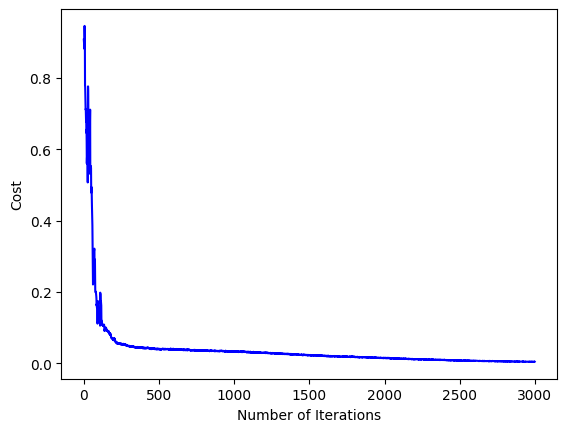

In [14]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [15]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [16]:
e = []
F = []
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(Psi,b)
    e.append(x_exact - state/norm)
    # f = abs(np.dot(Psi,b))**2
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

Text(0.5, 0, 'Iteration')

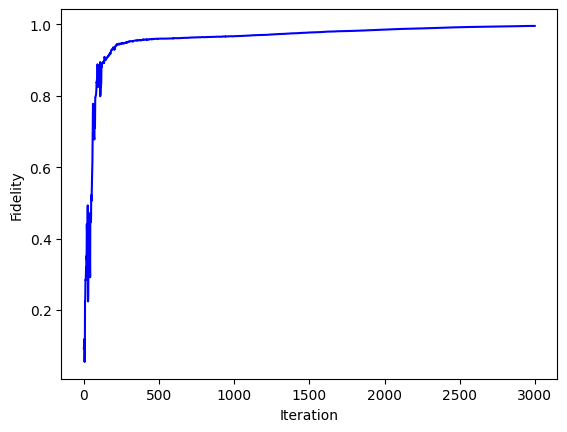

In [17]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


In [18]:
norm_e[np.argmax(F)]

1.2909907867073802

In [19]:
ef = abs(np.array(e[np.argmax(F)]))
ef

array([0.05243472, 0.13239226, 0.14634086, 0.24841812, 0.34120572,
       0.41385398, 0.39222684, 0.40419744, 0.40306237, 0.3787907 ,
       0.47144652, 0.4263659 , 0.36970066, 0.29273586, 0.14164947,
       0.07687757])

Text(0.5, 0, 'Iteration')

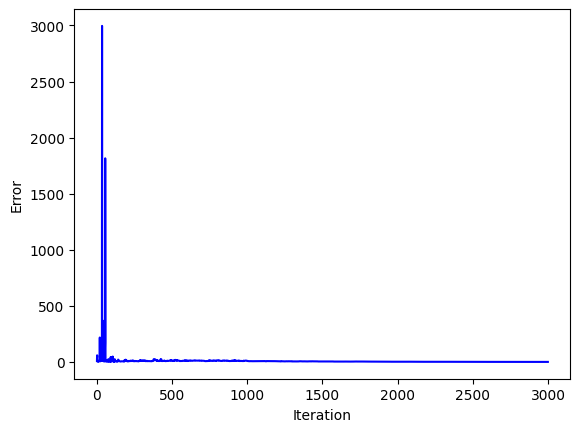

In [20]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(norm_e)),norm_e,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Error')
plt.xlabel('Iteration')

In [21]:
X_opt  = np.array(Statevector(ansatz(Params[-1])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [22]:
abs(np.array(e[-1]))

array([0.0491206 , 0.1299837 , 0.14908918, 0.25325098, 0.33924404,
       0.40971463, 0.39485899, 0.39960639, 0.40920032, 0.3829694 ,
       0.4788643 , 0.43417884, 0.37573713, 0.29042109, 0.14273079,
       0.07295191])

In [23]:
X_opt

array([0.02140196+0.j, 0.09167437+0.j, 0.13036683+0.j, 0.2014465 +0.j,
       0.25993798+0.j, 0.30699426+0.j, 0.31220169+0.j, 0.32127818+0.j,
       0.32779429+0.j, 0.3140294 +0.j, 0.348803  +0.j, 0.31765338+0.j,
       0.27583811+0.j, 0.2176416 +0.j, 0.12292445+0.j, 0.06215347+0.j])

In [24]:
print(F)

[0.09276698156017882, 0.09668117821408068, 0.10747802426820455, 0.11272142531966657, 0.11877412431509247, 0.05442481759390081, 0.07594499009360967, 0.10150513879013852, 0.22458626829147, 0.22473971598709444, 0.24616729659871786, 0.28495878096033334, 0.28389096844395223, 0.286820801233155, 0.31139175130736757, 0.32025207149747714, 0.3066427393831086, 0.35052994112316177, 0.34206942888076297, 0.37085824930663397, 0.4401761127268276, 0.4214422875942471, 0.42121581630039195, 0.42491744313856256, 0.4105923850474269, 0.4070972293313624, 0.49282206811974644, 0.3579066267179753, 0.2239200540054214, 0.23625682954346203, 0.29155164372809195, 0.3504077551747034, 0.38219585621274255, 0.385945110409905, 0.39086291707843795, 0.44908873013829326, 0.46227857708322384, 0.35548346817897614, 0.4493222398439339, 0.45549933744771454, 0.47084166010412043, 0.32051420472506337, 0.2917132311745098, 0.4533168229011726, 0.45756924325608384, 0.4634150470282627, 0.4523661643534804, 0.4457613281469929, 0.4513649990

In [25]:
print(norm_e)

[11.265312682569991, 60.094951441966224, 7.160822966537777, 4.655731161636367, 4.5267860012296195, 11.703084293153323, 9.802747747227036, 8.827144579711238, 6.517970899067706, 5.83870131744276, 8.575426900683118, 5.066555766588763, 5.04022335698373, 5.442274440711035, 6.122813285307218, 6.494330069087325, 13.72851979081437, 18.40547921212228, 34.53001567649774, 218.6021132534042, 41.230735541477486, 98.31298754997292, 58.941863121058574, 6.6189044530848635, 60.28872437902227, 23.639071901703563, 10.71761629551655, 10.357913709381773, 28.196286397223517, 37.27537197620017, 30.41827198713345, 30.957266688060923, 12.324391757505216, 12.496530135840514, 2995.6555064376, 77.57526007589627, 11.097119794998726, 370.5787705544443, 14.533658483585063, 13.405280330756694, 12.992123681694116, 15.245093653217976, 15.89754575598038, 8.12912524194838, 7.90509351793401, 9.380762110375144, 18.877971462295545, 41.920865755990754, 85.43694240272404, 4.678138363448688, 7.3253894533532335, 123.75421522698

In [26]:
min(norm_e)

1.110424538189962

In [27]:
1-max(F)

0.004321848357179858